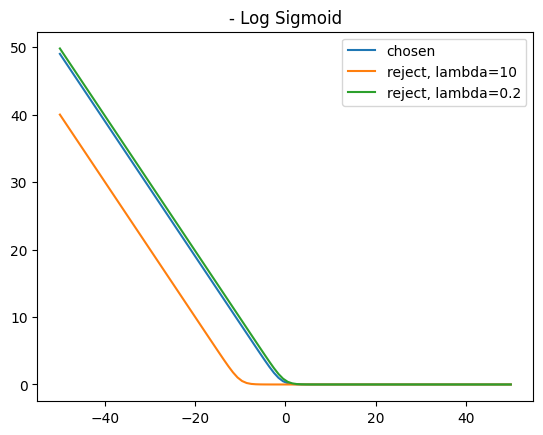

In [ ]:
# draw plot of log sigmoid function
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
import torch

def anchor_loss(r, beta, lambd, avg_r):
    logit = beta * (r - lambd * avg_r)
    return - F.logsigmoid(logit)

def negative_log_sigmoid(x, lambda_value=0, r=0):
    return - F.logsigmoid(x - lambda_value * r)

x = np.linspace(-50, 50, 100)
x = torch.tensor(x, dtype=torch.float32)
r = 0.8
y1 = negative_log_sigmoid(x, lambda_value=1, r=r)
y2 = negative_log_sigmoid(x, lambda_value=2, r=r)
#y3 = negative_log_sigmoid(x, lambda_value=0.2, r=r)

plt.plot(x, y1, label='chosen')
plt.plot(x, y2, label='reject, lambda=10')
plt.plot(x, y3, label='reject, lambda=0.2')
plt.title('- Log Sigmoid')
plt.legend()

plt.show()

In [13]:
log_sigmoid(x)


tensor([5.0000e+01, 4.8990e+01, 4.7980e+01, 4.6970e+01, 4.5960e+01, 4.4949e+01,
        4.3939e+01, 4.2929e+01, 4.1919e+01, 4.0909e+01, 3.9899e+01, 3.8889e+01,
        3.7879e+01, 3.6869e+01, 3.5859e+01, 3.4848e+01, 3.3838e+01, 3.2828e+01,
        3.1818e+01, 3.0808e+01, 2.9798e+01, 2.8788e+01, 2.7778e+01, 2.6768e+01,
        2.5758e+01, 2.4747e+01, 2.3737e+01, 2.2727e+01, 2.1717e+01, 2.0707e+01,
        1.9697e+01, 1.8687e+01, 1.7677e+01, 1.6667e+01, 1.5657e+01, 1.4646e+01,
        1.3636e+01, 1.2626e+01, 1.1616e+01, 1.0606e+01, 9.5960e+00, 8.5860e+00,
        7.5763e+00, 6.5671e+00, 5.5594e+00, 4.5560e+00, 3.5641e+00, 2.6022e+00,
        1.7138e+00, 9.7722e-01, 4.7217e-01, 1.9867e-01, 7.6996e-02, 2.8732e-02,
        1.0559e-02, 3.8585e-03, 1.4069e-03, 5.1260e-04, 1.8671e-04, 6.8001e-05,
        2.4765e-05, 9.0191e-06, 3.2846e-06, 1.1962e-06, 4.3563e-07, 1.5865e-07,
        5.7778e-08, 2.1042e-08, 7.6630e-09, 2.7907e-09, 1.0163e-09, 3.7013e-10,
        1.3479e-10, 4.9090e-11, 1.7878e-

In [14]:
data_path = '/data/all_checkpoints/MT_mistral7b_string+graph2string+graph_mdpo_5ep_lr_0124/lightning_logs/version_0/metrics.csv'

# read data
import pandas as pd
data = pd.read_csv(data_path)

# get data of columns including 'val'
val_data = data.loc[:, data.columns.str.contains('val')]
# remove rows with all nan
val_data = val_data.dropna(how='all')

down_thresholds = {
    'val/qm9_homo_lumo_gap/mae': 0.0039,
    'val/qm9_homo/mae': 0.0039,
    'val/qm9_lumo/mae': 0.0044,
    'val/smol-property_prediction-lipo/rmse': 1.18,
    'val/smol-property_prediction-esol/rmse': 0.93,
}

up_thresholds = {
    'val/smol-property_prediction-clintox/roc_auc': 0.869,
    'val/bace/roc_auc': 0.871,
    'val/smol-property_prediction-hiv/roc_auc': 0.774,
    'val/smol-property_prediction-bbbp/roc_auc': 0.835,
    'val/smol-property_prediction-sider/roc_auc': 0.761,
    'val/retrosynthesis/exact_match_ratio': 0.558,
    'val/forward_reaction_prediction/exact_match_ratio': 0.928,
    'val/reagent_prediction/exact_match_ratio': 0.223,
    'val/chebi-20-text2mol/exact_match_ratio': 0.46,
    'val/chebi-20-mol2text/bleu2': 0.587
}


# for rows in val_data, check number of columns that whose values are larger than thresholds
val_data['meets_up_thresholds'] = val_data.apply(lambda row: sum([row[col] >= up_thresholds[col] for col in up_thresholds if col in row]), axis=1)
val_data['meets_down_thresholds'] = val_data.apply(lambda row: sum([row[col] <= down_thresholds[col] for col in down_thresholds if col in row]), axis=1)
# get add of up and down thresholds
val_data['meets_thresholds'] = val_data['meets_up_thresholds'] + val_data['meets_down_thresholds']
val_data['meets_thresholds']

12      4
25      6
38      7
51      7
65      7
78      9
92      8
105     7
119     7
132     7
145     9
158    11
173     7
186    10
199    10
212    12
226    11
239    10
252    12
266    11
Name: meets_thresholds, dtype: int64

In [23]:
val_data_filtered = val_data[list(up_thresholds.keys()) + list(down_thresholds.keys())]
val_data_filtered = val_data_filtered[val_data['meets_thresholds'] >= 10]
val_data_filtered


,val/smol-property_prediction-clintox/roc_auc,val/bace/roc_auc,val/smol-property_prediction-hiv/roc_auc,val/smol-property_prediction-bbbp/roc_auc,val/smol-property_prediction-sider/roc_auc,val/retrosynthesis/exact_match_ratio,val/forward_reaction_prediction/exact_match_ratio,val/reagent_prediction/exact_match_ratio,val/chebi-20-text2mol/exact_match_ratio,val/chebi-20-mol2text/bleu2,val/qm9_homo_lumo_gap/mae,val/qm9_homo/mae,val/qm9_lumo/mae,val/smol-property_prediction-lipo/rmse,val/smol-property_prediction-esol/rmse
158,0.826866,0.817935,0.802031,0.880364,0.763426,0.558,0.934,0.225000,0.458182,56.241063,0.003731,0.003816,0.004380,1.018572,1.217211
186,0.809328,0.814402,0.799229,0.885547,0.762258,0.553,0.930,0.235000,0.457879,56.077543,0.003832,0.003706,0.004291,1.028295,1.192621
199,0.803358,0.811685,0.798435,0.887295,0.761922,0.557,0.928,0.233000,0.456952,56.011279,0.003763,0.003829,0.004219,1.018302,1.233147
212,0.804104,0.817572,0.802423,0.888380,0.762831,0.565,0.937,0.226158,0.462727,56.017662,0.003805,0.003872,0.004306,1.009495,1.158511
226,0.810448,0.813859,0.797749,0.883016,0.763432,0.565,0.931,0.235000,0.459697,56.203003,0.003771,0.003818,0.004182,1.010920,1.195748
239,0.806343,0.819112,0.798854,0.883197,0.763808,0.561,0.937,0.233000,0.458182,55.914920,0.003815,0.003903,0.004267,0.985762,1.184517
252,0.811940,0.820018,0.800044,0.885125,0.763135,0.564,0.936,0.232000,0.460303,56.083671,0.003830,0.003777,0.004244,1.034077,1.157476
266,0.819030,0.817572,0.800582,0.886572,0.763384,0.565,0.936,0.230000,0.458182,55.986813,0.003764,0.003772,0.004304,1.031239,1.125930


In [24]:
val_data_filtered.iloc[0]

val/smol-property_prediction-clintox/roc_auc          0.826866
val/bace/roc_auc                                      0.817935
val/smol-property_prediction-hiv/roc_auc              0.802031
val/smol-property_prediction-bbbp/roc_auc             0.880364
val/smol-property_prediction-sider/roc_auc            0.763426
val/retrosynthesis/exact_match_ratio                  0.558000
val/forward_reaction_prediction/exact_match_ratio     0.934000
val/reagent_prediction/exact_match_ratio              0.225000
val/chebi-20-text2mol/exact_match_ratio               0.458182
val/chebi-20-mol2text/bleu2                          56.241063
val/qm9_homo_lumo_gap/mae                             0.003731
val/qm9_homo/mae                                      0.003816
val/qm9_lumo/mae                                      0.004380
val/smol-property_prediction-lipo/rmse                1.018572
val/smol-property_prediction-esol/rmse                1.217211
Name: 158, dtype: float64

In [25]:
val_data_filtered.iloc[-1]

val/smol-property_prediction-clintox/roc_auc          0.819030
val/bace/roc_auc                                      0.817572
val/smol-property_prediction-hiv/roc_auc              0.800582
val/smol-property_prediction-bbbp/roc_auc             0.886572
val/smol-property_prediction-sider/roc_auc            0.763384
val/retrosynthesis/exact_match_ratio                  0.565000
val/forward_reaction_prediction/exact_match_ratio     0.936000
val/reagent_prediction/exact_match_ratio              0.230000
val/chebi-20-text2mol/exact_match_ratio               0.458182
val/chebi-20-mol2text/bleu2                          55.986813
val/qm9_homo_lumo_gap/mae                             0.003764
val/qm9_homo/mae                                      0.003772
val/qm9_lumo/mae                                      0.004304
val/smol-property_prediction-lipo/rmse                1.031239
val/smol-property_prediction-esol/rmse                1.125930
Name: 266, dtype: float64

In [18]:
val_data['meets_thresholds']

12      4
25      6
38      7
51      7
65      7
78      9
92      8
105     7
119     7
132     7
145     9
158    11
173     7
186    10
199    10
212    12
226    11
239    10
252    12
266    11
Name: meets_thresholds, dtype: int64

In [19]:
val_data.iloc[0]

val/bace/accuracy                          0.644737
val/bace/avg_loss                         36.463476
val/bace/f1                                0.727273
val/bace/instance_loss                    37.023426
val/bace/logps/chosen                    -54.684776
                                            ...    
val/smol-retrosynthesis/validity_ratio     0.998797
val/total_loss                            30.275705
meets_up_thresholds                        2.000000
meets_down_thresholds                      2.000000
meets_thresholds                           4.000000
Name: 12, Length: 292, dtype: float64

In [20]:
val_data['meets_thresholds']

12      4
25      6
38      7
51      7
65      7
78      9
92      8
105     7
119     7
132     7
145     9
158    11
173     7
186    10
199    10
212    12
226    11
239    10
252    12
266    11
Name: meets_thresholds, dtype: int64

In [21]:
val_data.columns

Index(['val/bace/accuracy', 'val/bace/avg_loss', 'val/bace/f1',
       'val/bace/instance_loss', 'val/bace/logps/chosen',
       'val/bace/logps/rejected', 'val/bace/precision', 'val/bace/recall',
       'val/bace/rewards/accuracies', 'val/bace/rewards/chosen',
       ...
       'val/smol-retrosynthesis/rewards/accuracies',
       'val/smol-retrosynthesis/rewards/chosen',
       'val/smol-retrosynthesis/rewards/margins',
       'val/smol-retrosynthesis/rewards/rejected',
       'val/smol-retrosynthesis/simpo_loss',
       'val/smol-retrosynthesis/validity_ratio', 'val/total_loss',
       'meets_up_thresholds', 'meets_down_thresholds', 'meets_thresholds'],
      dtype='object', length=292)

In [22]:
column_names = list(val_data.columns)
selected_columns = []
for column in column_names:
    for metric in metric_list:
        if metric in column:
            selected_columns.append(column)

NameError: name 'metric_list' is not defined

In [17]:
selected_columns

['val/bace/roc_auc',
 'val/chebi-20-mol2text/meteor',
 'val/chebi-20-mol2text/rouge1',
 'val/chebi-20-mol2text/rouge2',
 'val/chebi-20-mol2text/rougeL',
 'val/qm9_homo/mae',
 'val/qm9_homo_lumo_gap/mae',
 'val/qm9_lumo/mae',
 'val/smol-molecule_captioning/meteor',
 'val/smol-molecule_captioning/rouge1',
 'val/smol-molecule_captioning/rouge2',
 'val/smol-molecule_captioning/rougeL',
 'val/smol-property_prediction-bbbp/roc_auc',
 'val/smol-property_prediction-clintox/roc_auc',
 'val/smol-property_prediction-esol/mae',
 'val/smol-property_prediction-hiv/roc_auc',
 'val/smol-property_prediction-lipo/mae',
 'val/smol-property_prediction-sider/roc_auc']

In [7]:
# get columen names
column_names = val_data.columns

In [10]:
wo_simpo_accuracy = [
    0.45, 0.57, 0.28, 0.43, 0.09, 0.53, 0.51, 0.48, 0.41, 0.36, 0.66, 0.44, 0.46, 0.44, 0.01, 0.50, 0.46, 0.46, 0.45
]
w_simpo_accuracy = [
    0.05, 0.05, 0.05, 0.08, 0.01, 0.85, 0.98, 0.98, 0.02, 0.08, 0.08, 0.22, 0.69, 0.85, 0.03, 0.47, 0.97, 0.93, 0.56
]
len(wo_simpo_accuracy), len(w_simpo_accuracy)

(19, 19)

In [43]:
forward_data_path = 'forward.csv'
retro_data_path = 'retro.csv'
reagent_data_path = 'reagent.csv'
smolforward_data_path = 'smolforward.csv'
smolretro_data_path = 'smolretro.csv'

forward_data = pd.read_csv(forward_data_path)
retro_data = pd.read_csv(retro_data_path)
reagent_data = pd.read_csv(reagent_data_path)
smolforward_data = pd.read_csv(smolforward_data_path)
smolretro_data = pd.read_csv(smolretro_data_path)

In [15]:
forward_data

,trainer/global_step,MT_mistral7b_string+graph2string+graph_5ep_lr2e-5_0124 - _step,MT_mistral7b_string+graph2string+graph_5ep_lr2e-5_0124 - _step__MIN,MT_mistral7b_string+graph2string+graph_5ep_lr2e-5_0124 - _step__MAX,MT_mistral7b_string+graph2string+graph_5ep_lr2e-5_0124 - val/forward_reaction_prediction/rewards/accuracies,MT_mistral7b_string+graph2string+graph_5ep_lr2e-5_0124 - val/forward_reaction_prediction/rewards/accuracies__MIN,MT_mistral7b_string+graph2string+graph_5ep_lr2e-5_0124 - val/forward_reaction_prediction/rewards/accuracies__MAX,MT_mistral7b_string+graph2string+graph_mdpo_5ep_lr2e-5_0124 - _step,MT_mistral7b_string+graph2string+graph_mdpo_5ep_lr2e-5_0124 - _step__MIN,MT_mistral7b_string+graph2string+graph_mdpo_5ep_lr2e-5_0124 - _step__MAX,MT_mistral7b_string+graph2string+graph_mdpo_5ep_lr2e-5_0124 - val/forward_reaction_prediction/rewards/accuracies,MT_mistral7b_string+graph2string+graph_mdpo_5ep_lr2e-5_0124 - val/forward_reaction_prediction/rewards/accuracies__MIN,MT_mistral7b_string+graph2string+graph_mdpo_5ep_lr2e-5_0124 - val/forward_reaction_prediction/rewards/accuracies__MAX
0,607,12,12,12,0.507812,0.507812,0.507812,12.0,12.0,12.0,0.484375,0.484375,0.484375
1,1215,25,25,25,0.500000,0.500000,0.500000,25.0,25.0,25.0,0.898438,0.898438,0.898438
2,1823,38,38,38,0.492188,0.492188,0.492188,38.0,38.0,38.0,0.960938,0.960938,0.960938
3,2430,51,51,51,0.492188,0.492188,0.492188,51.0,51.0,51.0,0.937500,0.937500,0.937500
4,3038,65,65,65,0.523438,0.523438,0.523438,65.0,65.0,65.0,0.929688,0.929688,0.929688
5,3646,78,78,78,0.562500,0.562500,0.562500,78.0,78.0,78.0,0.976562,0.976562,0.976562
6,4254,92,92,92,0.578125,0.578125,0.578125,92.0,92.0,92.0,0.789062,0.789062,0.789062
7,4861,105,105,105,0.640625,0.640625,0.640625,105.0,105.0,105.0,0.968750,0.968750,0.968750
8,5469,119,119,119,0.476562,0.476562,0.476562,119.0,119.0,119.0,0.968750,0.968750,0.968750
9,6077,132,132,132,0.554688,0.554688,0.554688,132.0,132.0,132.0,0.960938,0.960938,0.960938


In [46]:
forward_data
# get value of column 'MT_mistral7b_string+graph2string+graph_mdpo_5ep_lr2e-5_0124 - val/forward_reaction_prediction/rewards/accuracies'
forward_data = forward_data.dropna(how='all')
simpo_forward_y = forward_data['MT_mistral7b_string+graph2string+graph_mdpo_5ep_lr2e-5_0124 - val/forward_reaction_prediction/rewards/accuracies']
nosimpo_forward_y = forward_data['MT_mistral7b_string+graph2string+graph_5ep_lr2e-5_0124 - val/forward_reaction_prediction/rewards/accuracies']
forward_x = forward_data['trainer/global_step']


simpo_retro_data = retro_data.dropna(how='all')
simpo_retro_y = retro_data['MT_mistral7b_string+graph2string+graph_mdpo_5ep_lr2e-5_0124 - val/retrosynthesis/rewards/accuracies']
nosimpo_retro_y = retro_data['MT_mistral7b_string+graph2string+graph_5ep_lr2e-5_0124 - val/retrosynthesis/rewards/accuracies']
retro_x = retro_data['trainer/global_step']

simpo_reagent_data = reagent_data.dropna(how='all')
simpo_reagent_y = reagent_data['MT_mistral7b_string+graph2string+graph_mdpo_5ep_lr2e-5_0124 - val/reagent_prediction/rewards/accuracies']
nosimpo_reagent_y = reagent_data['MT_mistral7b_string+graph2string+graph_5ep_lr2e-5_0124 - val/reagent_prediction/rewards/accuracies']
reagent_x = reagent_data['trainer/global_step']

smolforward_data = smolforward_data.dropna(how='all')
simpo_smolforward_y = smolforward_data['MT_mistral7b_string+graph2string+graph_mdpo_5ep_lr2e-5_0124 - val/smol-forward_synthesis/rewards/accuracies']
nosimpo_smolforward_y = smolforward_data['MT_mistral7b_string+graph2string+graph_5ep_lr2e-5_0124 - val/smol-forward_synthesis/rewards/accuracies']
smolforward_x = smolforward_data['trainer/global_step']

smolretro_data = smolretro_data.dropna(how='all')
simpo_smolretro_y = smolretro_data['MT_mistral7b_string+graph2string+graph_mdpo_5ep_lr2e-5_0124 - val/smol-retrosynthesis/rewards/accuracies']
nosimpo_smolretro_y = smolretro_data['MT_mistral7b_string+graph2string+graph_5ep_lr2e-5_0124 - val/smol-retrosynthesis/rewards/accuracies']
smolretro_x = smolretro_data['trainer/global_step']

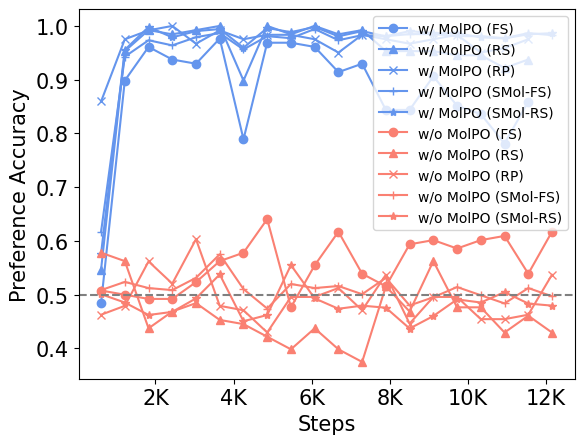

In [47]:
# draw plot with x, y
import matplotlib.pyplot as plt
plt.plot(forward_x, simpo_forward_y, label='w/ MolPO (FS)', color='cornflowerblue', marker='o')
plt.plot(retro_x, simpo_retro_y, label='w/ MolPO (RS)', color='cornflowerblue', marker='^')
plt.plot(reagent_x, simpo_reagent_y, label='w/ MolPO (RP)', color='cornflowerblue', marker='x')

plt.plot(smolforward_x, simpo_smolforward_y, label='w/ MolPO (SMol-FS)', color='cornflowerblue', marker='+')
plt.plot(smolretro_x, simpo_smolretro_y, label='w/ MolPO (SMol-RS)', color='cornflowerblue', marker='*')


plt.plot(forward_x, nosimpo_forward_y, label='w/o MolPO (FS)', color='salmon', marker='o')
plt.plot(retro_x, nosimpo_retro_y, label='w/o MolPO (RS)', color='salmon', marker='^')
plt.plot(reagent_x, nosimpo_reagent_y, label='w/o MolPO (RP)', color='salmon', marker='x')

plt.plot(smolforward_x, nosimpo_smolforward_y, label='w/o MolPO (SMol-FS)', color='salmon', marker='+')
plt.plot(smolretro_x, nosimpo_smolretro_y, label='w/o MolPO (SMol-RS)', color='salmon', marker='*')
# horizontal line at y=0.5
plt.axhline(y=0.5, color='gray', linestyle='--')


fontsize = 15
# y axislabel Preference Accuracy
plt.ylabel('Preference Accuracy', fontsize=fontsize)
# x axislabel Steps
plt.xlabel('Steps', fontsize=fontsize)
# x ticklabels [2K, 4K, 6K, 8K, 10K, 120K]
plt.xticks([2000, 4000, 6000, 8000, 10000, 12000], ['2K', '4K', '6K', '8K', '10K', '12K'])
# enlarge axis label font size
plt.tick_params(axis='both', which='major', labelsize=fontsize)

# position legent to the right upper
plt.legend(loc='upper right')

In [3]:
csv_path = '/text-mol/nohup_out/wandb_export_2025-04-10T16_13_02.558+09_00.csv'
import pandas as pd
data = pd.read_csv(csv_path)
data = data.dropna(how='all')

In [28]:
data
#get column names
# get columns that contains 'val/qm9_homo/mae'
val_data = data.loc[:, data.columns.str.endswith('val/qm9_homo/mae')]
# remove nan
val_data = val_data.dropna(how='all')
column_names = val_data.columns

In [21]:
column_names

Index(['qm9_homo_graph_only_TokenGT_grad-clip-0.5_12ep_0409 - val/qm9_homo/mae',
       'qm9_homo_graph_only_tokengt_/data/all_checkpoints/Custom_gnn_models/TokenGT/best-model.ckpt_12ep_0409 - val/qm9_homo/mae',
       'qm9_homo_graph_only_tokengt_scratch_12ep_0409 - val/qm9_homo/mae',
       'qm9_homo_molpo_rej-1.2_12ep_0405 - val/qm9_homo/mae',
       'qm9_homo_mlp_string_only_12ep_0318 - val/qm9_homo/mae',
       'qm9_homo_qformer_graph_only_12ep_0318 - val/qm9_homo/mae'],
      dtype='object')

In [31]:
tokengt_graph_only_ptr_clip = column_names[0]
data_tokengt_graph_only_ptr_clip = val_data[tokengt_graph_only_ptr_clip].dropna()

tokengt_graph_only_ptr = column_names[1]
data_tokengt_graph_only_ptr = val_data[tokengt_graph_only_ptr].dropna()

tokengt_graph_only_noptr = column_names[2]
data_tokengt_graph_only_noptr = val_data[tokengt_graph_only_noptr].dropna()

gine_molpo = column_names[3]
data_gine_molpo = val_data[gine_molpo].dropna()

string_only = column_names[4]
data_string_only = val_data[string_only].dropna()

gine_graph_only = column_names[5]
data_gine_graph_only = val_data[gine_graph_only].dropna()

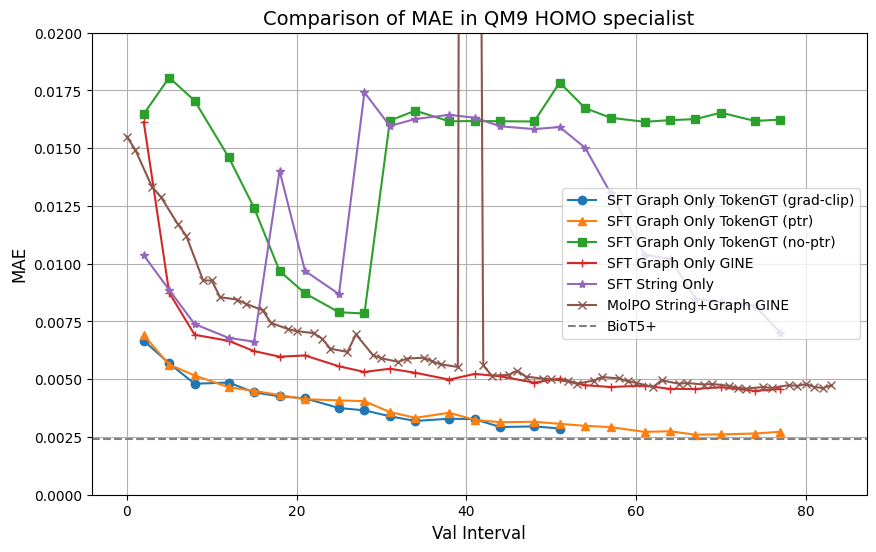

In [49]:
import matplotlib.pyplot as plt

# draw line plot using all of them
plt.figure(figsize=(10, 6))

# Plot each series
plt.plot(data_tokengt_graph_only_ptr_clip, label='SFT Graph Only TokenGT (grad-clip)', marker='o')
plt.plot(data_tokengt_graph_only_ptr, label='SFT Graph Only TokenGT (ptr)', marker='^')
plt.plot(data_tokengt_graph_only_noptr, label='SFT Graph Only TokenGT (no-ptr)', marker='s')
plt.plot(data_gine_graph_only, label='SFT Graph Only GINE', marker='+')
plt.plot(data_string_only, label='SFT String Only', marker='*')
plt.plot(data_gine_molpo, label='MolPO String+Graph GINE', marker='x')

# draw horizontal line at y=0.0024
plt.axhline(y=0.0024, color='gray', linestyle='--', label='BioT5+')

plt.ylim(0, 0.02)  # Set y-axis limits

# Add labels and legend
plt.xlabel('Val Interval', fontsize=12)
plt.ylabel('MAE', fontsize=12)
plt.title('Comparison of MAE in QM9 HOMO specialist', fontsize=14)
plt.legend()
plt.grid(True)
plt.show()